# Baseline Model Training and Evaluation

This notebook trains and evaluates baseline ML models using extracted acoustic + multifractal features.

## What it does
- Loads feature tables from `src.features`
- Builds a model-ready dataset
- Trains multiple baseline classifiers
- Compares performance (accuracy, balanced accuracy, macro-F1)
- Visualizes confusion matrices

> Note: current splits are random sample-level. For clinically safer evaluation, consider speaker-grouped splits in a follow-up.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

sys.path.append("..")
from src.features import FeatureOptions, load_feature_tables

g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Keep this small for quick iteration; set to None for full training set
MAX_SAMPLES_PER_CLASS = 200

opts = FeatureOptions(
    prefix=Path(".."),
    include_splits=True,
    random_seed=RANDOM_SEED,
    max_samples_per_class=MAX_SAMPLES_PER_CLASS,
)

opts

FeatureOptions(prefix=WindowsPath('..'), input_manifest=WindowsPath('data/processed/manifests/dataset_manifest.csv'), output_core=WindowsPath('data/processed/features/sample_core.csv'), output_acoustic=WindowsPath('data/processed/features/acoustic_features.csv'), output_multifractal=WindowsPath('data/processed/features/multifractal_features.csv'), output_splits=WindowsPath('data/processed/features/sample_splits.csv'), output_summary_json=WindowsPath('data/processed/features/feature_summary.json'), include_splits=True, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_seed=42, max_samples_per_class=200, normalize_audio=True, target_sample_rate=None, mfdfa_order=1, mfdfa_q_min=-5.0, mfdfa_q_max=5.0, mfdfa_q_step=1.0, mfdfa_num_scales=20)

In [3]:
tables = load_feature_tables(options=opts, build_if_missing=True, save_if_built=True)

for name, df in tables.items():
    print(f"{name}: {df.shape}")

core_df = tables["core"].copy()
acoustic_df = tables["acoustic"].copy()
multifractal_df = tables["multifractal"].copy()
splits_df = tables.get("splits", pd.DataFrame())

core: (1214, 18)
acoustic: (1214, 87)
multifractal: (1214, 17)
splits: (1214, 3)


In [4]:
# Build one training table
df = core_df.merge(acoustic_df, on="sample_key", how="left")
df = df.merge(multifractal_df, on="sample_key", how="left")
if not splits_df.empty:
    df = df.merge(splits_df, on="sample_key", how="left")

# Filter to successfully extracted samples
if "feature_status" in df.columns:
    df = df[df["feature_status"].isin(["ok", "partial_failure"])].copy()
if "acoustic_status" in df.columns:
    df = df[df["acoustic_status"] == "ok"].copy()
if "mf_status" in df.columns:
    df = df[df["mf_status"] == "ok"].copy()

df.shape

(1214, 122)

In [5]:
# Select target and features
target_col = "pathology_de" if "pathology_de" in df.columns else "pathology_en"

exclude_cols = {
    "sample_key",
    "duplicate_class_key",
    "recording_id",
    "speaker_id",
    "wav_path",
    "feature_status",
    "feature_error",
    "acoustic_status",
    "acoustic_error",
    "mf_status",
    "mf_error",
    "split",
    "split_seed",
    "pathology_de",
    "pathology_en",
}

numeric_feature_cols = [
    c for c in df.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])
]

X = df[numeric_feature_cols].copy()
y = df[target_col].astype(str).copy()

print(f"Samples: {len(df)}")
print(f"Classes: {y.nunique()}")
print(f"Numeric features: {len(numeric_feature_cols)}")

Samples: 1214
Classes: 7
Numeric features: 104


In [6]:
# Train/test split: prefer precomputed split table when available
if "split" in df.columns and df["split"].notna().any():
    train_mask = df["split"] == "train"
    val_mask = df["split"] == "val"
    test_mask = df["split"] == "test"

    X_train = X[train_mask | val_mask]
    y_train = y[train_mask | val_mask]
    X_test = X[test_mask]
    y_test = y[test_mask]

    if len(X_test) == 0:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
        )
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
    )

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1031, 104)
Test shape: (183, 104)


In [7]:
# Shared preprocessing for numeric feature space
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[("num", numeric_transformer, numeric_feature_cols)],
    remainder="drop",
)

In [8]:
models = {
    "LogReg": LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_SEED),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_SEED,
        class_weight="balanced_subsample",
        n_jobs=-1,
    ),
    "SVM-RBF": SVC(kernel="rbf", C=3.0, gamma="scale", class_weight="balanced"),
}

results = []
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", model),
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro", zero_division=0)

    results.append({
        "model": name,
        "accuracy": acc,
        "balanced_accuracy": bacc,
        "f1_macro": f1m,
    })

    trained_pipelines[name] = (pipe, y_pred)

results_df = pd.DataFrame(results).sort_values(by="f1_macro", ascending=False)
results_df

,model,accuracy,balanced_accuracy,f1_macro
0,LogReg,0.491803,0.503854,0.521660
1,RandomForest,0.551913,0.488255,0.483815
2,SVM-RBF,0.524590,0.464220,0.461635


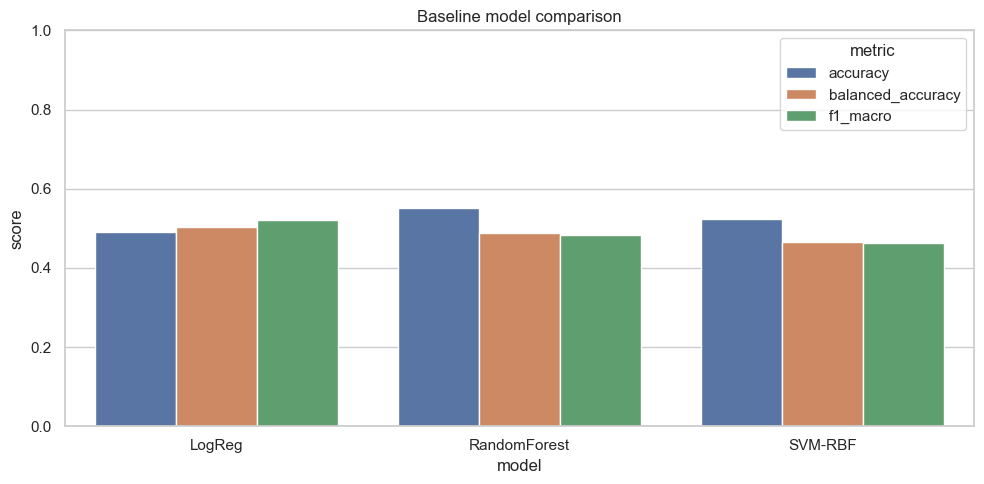

In [9]:
sns.set_theme(style="whitegrid")
plot_df = results_df.melt(id_vars="model", var_name="metric", value_name="score")

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.ylim(0, 1)
plt.title("Baseline model comparison")
plt.tight_layout()
plt.show()

In [10]:
best_model_name = results_df.iloc[0]["model"]
best_pipe, best_pred = trained_pipelines[best_model_name]

print(f"Best model: {best_model_name}")
print(classification_report(y_test, best_pred, zero_division=0))

Best model: LogReg
                        precision    recall  f1-score   support

      Morbus Parkinson       1.00      0.50      0.67         2
   Phonationsknötchen       0.47      0.50      0.48        28
          Reinke Ödem       0.33      0.29      0.31        34
       Rekurrensparese       0.39      0.50      0.44        28
Spasmodische Dysphonie       0.41      0.45      0.43        31
      Stimmlippenpolyp       0.38      0.28      0.32        32
               healthy       1.00      1.00      1.00        28

              accuracy                           0.49       183
             macro avg       0.57      0.50      0.52       183
          weighted avg       0.49      0.49      0.49       183



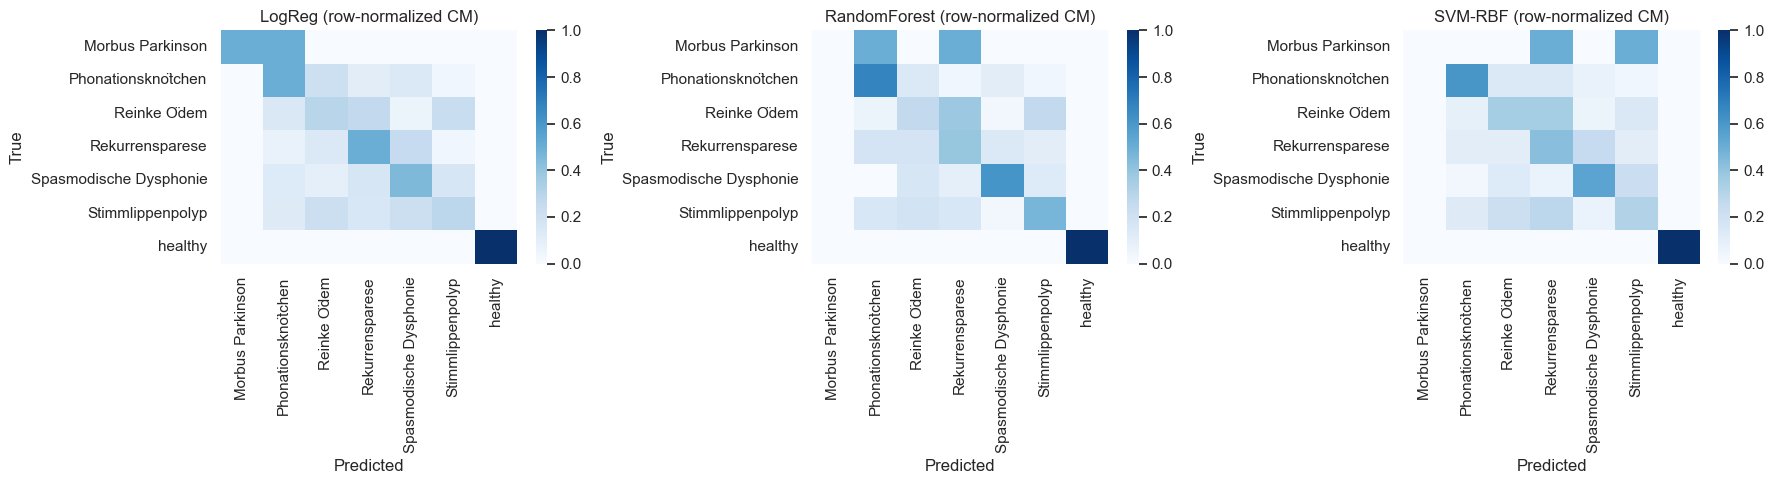

In [11]:
labels = sorted(y_test.unique())

n_models = len(trained_pipelines)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5), squeeze=False)

for i, (name, (_, pred)) in enumerate(trained_pipelines.items()):
    cm = confusion_matrix(y_test, pred, labels=labels)
    cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

    sns.heatmap(
        cm_norm,
        annot=False,
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=axes[0, i],
    )
    axes[0, i].set_title(f"{name} (row-normalized CM)")
    axes[0, i].set_xlabel("Predicted")
    axes[0, i].set_ylabel("True")

plt.tight_layout()
plt.show()

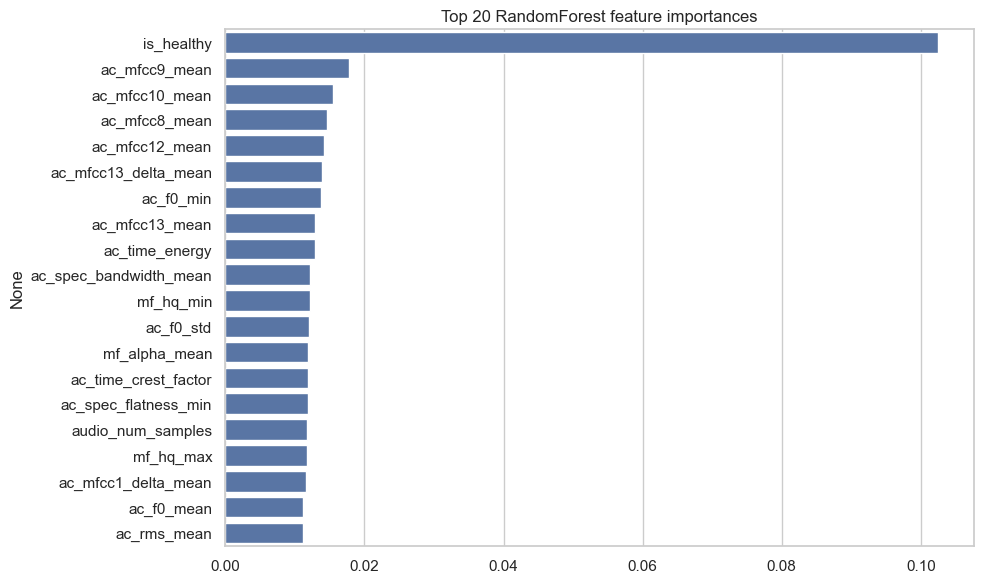

In [12]:
# Optional: inspect top RF feature importances
if "RandomForest" in trained_pipelines:
    rf_pipe, _ = trained_pipelines["RandomForest"]
    rf_model = rf_pipe.named_steps["model"]

    importances = pd.Series(rf_model.feature_importances_, index=numeric_feature_cols)
    top_imp = importances.sort_values(ascending=False).head(20)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_imp.values, y=top_imp.index)
    plt.title("Top 20 RandomForest feature importances")
    plt.tight_layout()
    plt.show()

    top_imp.to_frame("importance")

## Next recommendations

- Add speaker-grouped splits for leakage-safe evaluation.
- Run hyperparameter search on the best baseline.
- Compare acoustic-only vs multifractal-only vs fused feature sets.